#### Librerías

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Datos

In [11]:
df=pd.read_csv("data/car_fuel_efficiency.csv")
df.columns=df.columns.str.lower().str.replace(" ","_")
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [12]:
cols=list(df.dtypes[df.dtypes=='object'].index)

for col in cols:
    df[col]=df[col].str.lower().str.replace(" ","_") #reemplazamos espacios por guiones bajos y pasamos a minusculas
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,europe,gasoline,front-wheel_drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,europe,diesel,front-wheel_drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,asia,gasoline,front-wheel_drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,europe,gasoline,front-wheel_drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,usa,diesel,front-wheel_drive,3,2580,7,304.0,4510,17.5,31.0


In [13]:
df.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='object')

In [14]:
variables=['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']
df_red=df[variables]


Como se ve a continuación, la variable de la eficiencia del combustible tiene una distribución bastante asimétrica, es decir, no tiene marcada ni cola izquierda ni cola derecha

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

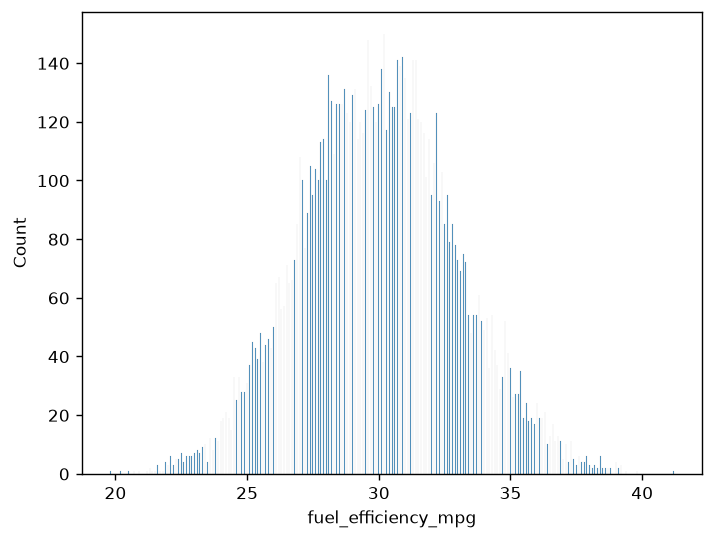

In [15]:
sns.histplot(df_red.fuel_efficiency_mpg, bins=1000)

##### Pregunta 1: hay una columna con valores nulos. ¿Cuál es?

#### Respuesta: la columna 'horsepower'

In [16]:
df_red.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

##### Pregunta 2: ¿Cuál es la mediana de la columna 'horsepower'?

##### Respuesta: $149.65729212983547$

In [17]:
df_red['horsepower'].median()

np.float64(254.0)

##### Preparación y separación de los datos

In [18]:
n=len(df)
n_val=int(n*0.2)
n_test=int(n*0.2)
n_train=n-n_val-n_test
n,n_val+n_test+n_train 

(10000, 10000)

In [19]:
np.random.seed(42)
idx=np.arange(n)
np.random.shuffle(idx)
idx #indices aleatorios

array([6252, 4684, 1731, ..., 5390,  860, 7270], shape=(10000,))

In [20]:
df_red_train=df_red.iloc[idx[:n_train]]
df_red_val=df_red.iloc[idx[n_train:n_train+n_val]]
df_red_test=df_red.iloc[idx[n_train+n_val:]] # uso idx para que los conjuntos de train, validation y test sean aleatorios

In [21]:
df_red_train=df_red_train.reset_index(drop=True)
df_red_val=df_red_val.reset_index(drop=True)
df_red_test=df_red_test.reset_index(drop=True)

In [22]:
y_train=df_red_train.fuel_efficiency_mpg.values # el .values sirve para haerlo como una matriz
y_val=df_red_val.fuel_efficiency_mpg.values
y_test=df_red_test.fuel_efficiency_mpg.values

In [23]:
del df_red_train['fuel_efficiency_mpg']
del df_red_val['fuel_efficiency_mpg']
del df_red_test['fuel_efficiency_mpg']

##### Question 3
- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 3 decimal digits using round(score, 3)
- Which option gives better RMSE?

In [34]:
Xs=['engine_displacement','horsepower','vehicle_weight','model_year']

In [35]:
def prepare_x_mean(df,df_train):
    df_num=df[Xs].copy()
    df_num=df_num.fillna(df_train['horsepower'].mean())
    x=df_num.values
    return x

def prepare_x_zero(df):
    df_num=df[Xs].copy()
    df_num=df_num.fillna(0)
    x=df_num.values
    return x

def train_linear_regression(X,y):
    ones=np.ones(X.shape[0])
    X=np.column_stack([ones,X])
    XTX=X.T.dot(X)
    XTX_inv=np.linalg.inv(XTX)
    w_full=XTX_inv.dot(X.T).dot(y)
    return w_full[0],w_full[1:]

def rmse(y,y_pred):
    error=y-y_pred
    se=error**2
    mse=se.mean()
    return round(np.sqrt(mse),3)

In [38]:
x_train_mean=prepare_x_mean(df_red_train,df_red_train)
w0_mean,w_mean=train_linear_regression(x_train_mean,y_train)
y_pred=w0_mean+x_train_mean.dot(w_mean)
rmse(y_train,y_pred)

np.float64(2.198)

In [39]:
x_train_zero=prepare_x_zero(df_red_train)
w0_zero,w_zero=train_linear_regression(x_train_zero,y_train)
y_pred=w0_zero+x_train_zero.dot(w_zero)
rmse(y_train,y_pred)

np.float64(2.2)

##### Question 4
- Now let's train a regularized linear regression.
- For this question, fill the NAs with 0.
- Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
- Use RMSE to evaluate the model on the validation dataset.
- Round the RMSE scores to 4 decimal digits.
- Which r gives the best RMSE?

In [40]:
def train_linear_regression_reg(X,y,r=0.001):
    ones=np.ones(X.shape[0])
    X=np.column_stack([ones,X])
    XTX=X.T.dot(X)
    XTX=XTX+r*np.eye(XTX.shape[0]) # shape[0] devuelve el número de filas de la matriz XTX, que es el mismo que el número de columnas, ya que XTX es una matriz cuadrada. Por lo tanto, np.eye(XTX.shape[0]) crea una matriz identidad del mismo tamaño que XTX, y al multiplicarla por 0.01 se obtiene una matriz diagonal con 0.01 en la diagonal principal y 0 en el resto de los elementos. Al sumar esta matriz a XTX, se obtiene una nueva matriz que es más estable numéricamente y que permite calcular su inversa sin problemas.
    XTX_inv=np.linalg.inv(XTX)
    w_full=XTX_inv.dot(X.T).dot(y)
    return w_full[0],w_full[1:]

In [41]:
for r in [0,0.01,0.1,1,5,10,100]:
    X_train=prepare_x_zero(df_red_train)
    w0,w=train_linear_regression_reg(X_train,y_train,r=r)
    X_val=prepare_x_zero(df_red_val)
    y_pred=w0+X_val.dot(w)
    print(f"r={r}, RMSE={rmse(y_val,y_pred)}")

r=0, RMSE=2.205
r=0.01, RMSE=2.206
r=0.1, RMSE=2.224
r=1, RMSE=2.349
r=5, RMSE=2.409
r=10, RMSE=2.419
r=100, RMSE=2.429


##### Question 5
- We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
- Round the result to 3 decimal digits (round(std, 3))

In [42]:
rmse_scores = [] 

for seed in [0,1,2,3,4,5,6,7,8,9]:
    np.random.seed(seed)
    n = len(df_red)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test
    
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_train = df_red.iloc[idx[:n_train]]
    df_val = df_red.iloc[idx[n_train:n_train+n_val]]
    df_test = df_red.iloc[idx[n_train+n_val:]]
    
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True) 
    df_test = df_test.reset_index(drop=True)
    
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values
    
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']
    
    X_train = prepare_x_zero(df_train)
    w0_zero, w_zero = train_linear_regression(X_train, y_train)
    
    X_val = prepare_x_zero(df_val)
    y_pred = w0_zero + X_val.dot(w_zero)
    
    score = rmse(y_val, y_pred)
    print(f"Seed {seed} -> RMSE={score}")
    
    rmse_scores.append(score)

std = np.std(rmse_scores)
print(f"\nDesviación estándar de los RMSE: {round(std, 3)}")

Seed 0 -> RMSE=2.239
Seed 1 -> RMSE=2.202
Seed 2 -> RMSE=2.163
Seed 3 -> RMSE=2.204
Seed 4 -> RMSE=2.202
Seed 5 -> RMSE=2.246
Seed 6 -> RMSE=2.27
Seed 7 -> RMSE=2.191
Seed 8 -> RMSE=2.217
Seed 9 -> RMSE=2.207

Desviación estándar de los RMSE: 0.029


##### Question 6
- Split the dataset like previously, use seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with r=0.001.
- What's the RMSE on the test dataset?

In [43]:
np.random.seed(9)
n = len(df_red)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test
 
idx = np.arange(n)
np.random.shuffle(idx)
 
df_train_val = df_red.iloc[idx[:n_train+n_val]]
df_test = df_red.iloc[idx[n_train+n_val:]]
    
df_train_val = df_train_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train_val = df_train_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

X_train_val = prepare_x_zero(df_train_val)
w0_zero, w_zero = train_linear_regression_reg(X_train_val, y_train_val,r=0.001)
    
X_test = prepare_x_zero(df_test)
y_pred = w0_zero + X_test.dot(w_zero)
    
score = rmse(y_test, y_pred)
round(score,3)

np.float64(2.236)